In [135]:
# Homework 3 code

import cv2 as cv
import numpy as np
import os
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

In [136]:
DATA_PATH = "Fish"

dataset = keras.utils.image_dataset_from_directory(
    directory=DATA_PATH,
    validation_split=0.30,
    subset="both",
    seed=67,
    image_size=(128, 128), # Part 2 req
    batch_size=32
)


Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.


In [137]:
train_set = dataset[0]
remaining = dataset[1]

# remaining has 30% so cutting it into 2
remaining_set = tf.data.experimental.cardinality(remaining)

val_set = remaining.take(remaining_set // 2)
test_set = remaining.skip(remaining_set // 2)


In [138]:
class_names = train_set.class_names

In [139]:
from keras import layers

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(.2),
    layers.RandomBrightness(.3)
])

In [140]:
model = keras.Sequential([
    data_aug,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_50 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_46 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_138 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_138               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_139               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_140 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_140               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_44 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [141]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [142]:
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.3006 - loss: 1.7461 - val_accuracy: 0.4875 - val_loss: 1.4580
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4480 - loss: 1.4070 - val_accuracy: 0.5125 - val_loss: 1.3729
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5449 - loss: 1.1899 - val_accuracy: 0.5000 - val_loss: 1.4875
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5857 - loss: 1.1031 - val_accuracy: 0.6438 - val_loss: 1.0977
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6250 - loss: 0.9707 - val_accuracy: 0.6750 - val_loss: 0.9704
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6770 - loss: 0.8539 - val_accuracy: 0.6687 - val_loss: 0.8587
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6896 - loss: 0.8351 - val_accuracy: 0.7312 - val_loss: 0.8117
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7205 - loss: 0.7396 - val_accuracy: 0.7125 - v

In [143]:
model.save("baseline.keras")

In [144]:
test_loss, test_acc = model.evaluate(test_set)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7847 - loss: 0.6115


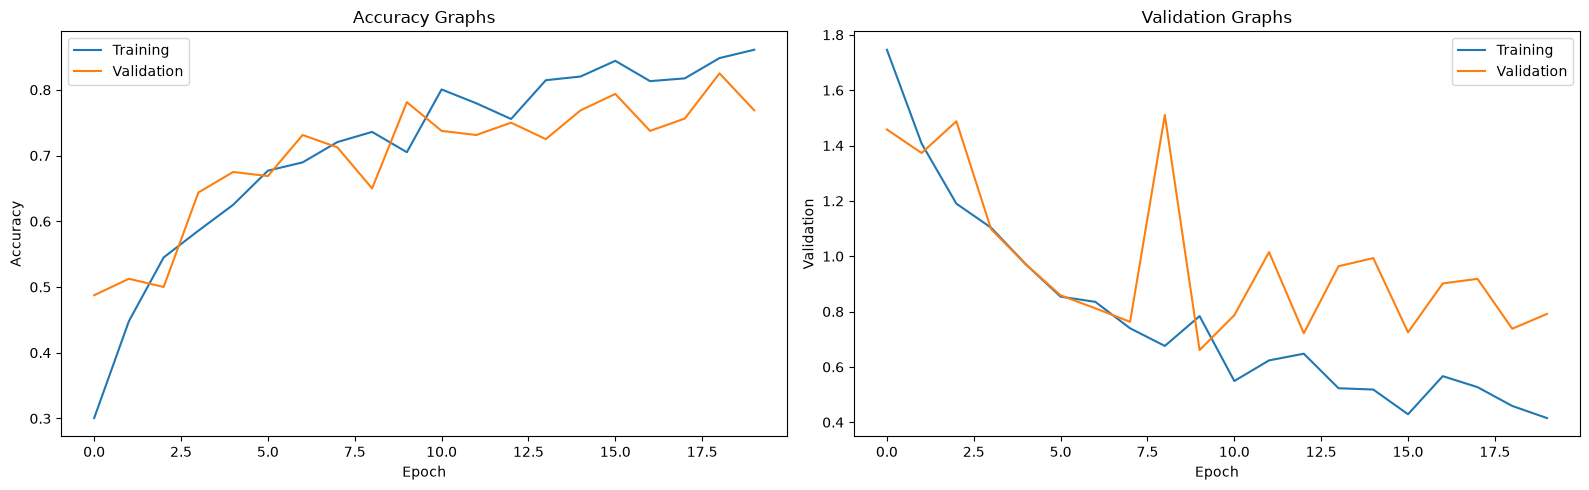

In [145]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs")

plt.tight_layout()
plt.show()

In [146]:
# helper funcs for the grid search

def dataset(batch_size, path):
    dataset = keras.utils.image_dataset_from_directory(
        directory=path,
        validation_split=0.30,
        subset="both",
        seed=67,
        image_size=(128, 128),
        batch_size=batch_size
    )
    train_set = dataset[0]
    remaining = dataset[1]
    remaining_set = tf.data.experimental.cardinality(remaining)
    val_set = remaining.take(remaining_set // 2)
    test_set = remaining.skip(remaining_set // 2)

    return train_set, val_set, test_set

def model(dropout, data_aug):
    model = keras.Sequential([
        data_aug,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.Dense(6, activation='softmax')
    ])
    return model

In [147]:
# Part 4

learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64]
dropouts = [0.3, 0.5]

best_val_acc = 0
best_history = None
best_params = None
best_model = None

model_history = []

for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for dropout in dropouts:
            train_set, val_set, test_set = dataset(batch_size, DATA_PATH)
            grid_model = model(dropout, data_aug)

            grid_model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )

            history = grid_model.fit(
                train_set,
                validation_data=val_set,
                epochs=35
            )

            val_acc = max(history.history["val_accuracy"])
            train_acc = max(history.history["accuracy"])
            params = (learning_rate, batch_size, dropout)
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_history = history
                best_params = params
                best_model = grid_model

            model_history.append((params, val_acc, train_acc))

            

best_model.save("best_model.keras")

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
Epoch 1/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.1994 - loss: 3.5953 - val_accuracy: 0.2250 - val_loss: 1.7498
Epoch 2/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1910 - loss: 1.7821 - val_accuracy: 0.1875 - val_loss: 1.7671
Epoch 3/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2205 - loss: 1.7747 - val_accuracy: 0.1813 - val_loss: 1.7842
Epoch 4/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1938 - loss: 1.7999 - val_accuracy: 0.1813 - val_loss: 1.7860
Epoch 5/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1854 - loss: 1.7667 - val_accuracy: 0.1875 - val_loss: 1.7606
Epoch 6/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2022 - loss: 1.7610 - val_accuracy: 0.1875 - val_loss: 1.7586
Epoch 7/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2022 - loss: 1.7634 - val_accuracy: 0.1875 - val_loss: 1.7589
Epoch 8/

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/stepWARNING:tensorflow:5 out of the last 14 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x1632487c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step
              precision    recall  f1-score   support

        Bete       0.81      0.71      0.75  

2026-07-18 01:31:57.961117: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


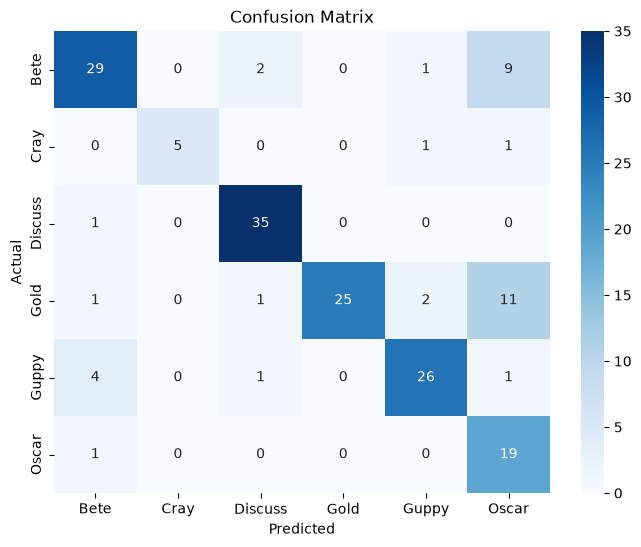

In [148]:
# Part 5

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_batch = best_params[1]
grid_train_ds, grid_val_ds, grid_test_ds = dataset(best_batch, DATA_PATH)

pred = best_model.predict(grid_test_ds)

y_pred = np.argmax(pred, axis=1)

y_true = np.concatenate([y for x, y in grid_test_ds])

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, class_accuracy):
    print(f"{name}: {acc:.3f}")

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

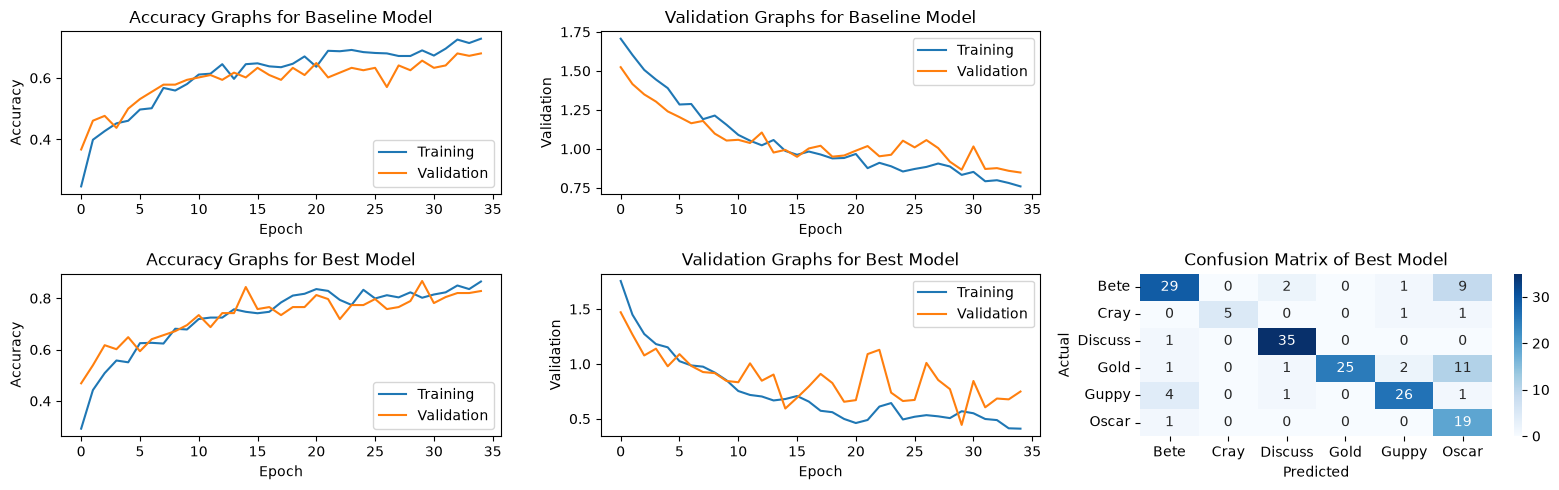

In [149]:
plt.figure(figsize=(16,5))

#baseline
plt.subplot(2,3,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs for Baseline Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs for Baseline Model")

#confusion matrix
plt.subplot(2,3,6)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix of Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

#best

plt.subplot(2,3,4)
plt.plot(best_history.history["accuracy"], label="Training")
plt.plot(best_history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs for Best Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,5)
plt.plot(best_history.history["loss"], label="Training")
plt.plot(best_history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs for Best Model")

plt.tight_layout()
plt.show()

In [150]:
for model_ in model_history:
    print(f"Learning Rate: {model_[0][0]} | Batch Size: {model_[0][1]}| Dropout: {model_[0][2]} | val accuracy: {model_[1]:.4f} | train accuracy: {model_[2]:.4f}")

Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.2250 | train accuracy: 0.2205
Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.4250 | train accuracy: 0.2402
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.3672 | train accuracy: 0.2065
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.2422 | train accuracy: 0.2051
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.8625 | train accuracy: 0.8680
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.8375 | train accuracy: 0.8357
Learning Rate: 0.001 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.8594 | train accuracy: 0.8722
Learning Rate: 0.001 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.8672 | train accuracy: 0.8652
Learning Rate: 0.0001 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.7188 | train accuracy: 0.7837
Learning Rate: 0.0001 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.7563 | train accuracy: 0.7598
Le

In [152]:
print(best_params)

(0.001, 64, 0.5)
